# How many parameters?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

import torch
from torchinfo import summary

In [2]:
from transformers import AutoModelForCausalLM, GPT2Tokenizer
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')

## Import GPT2 model

In [3]:
# dictionary of modelname:identifier
model_ids = {
    'small':  'gpt2',        # 124M
    'medium': 'gpt2-medium', # 355M
    'large':  'gpt2-large',  # 774M
}
#    'xl':     'gpt2-xl'      # 1.6B (including this model really slows things down...)
# } 

# load all models into a dictionary
models = {}
for name, id in model_ids.items():
    models[name] = AutoModelForCausalLM.from_pretrained(id)

In [4]:
models.keys()

dict_keys(['small', 'medium', 'large'])

In [5]:
# now you can iterate over them
for name, model in models.items():
    print(f'{sum(p.numel() for p in model.parameters()):13,} parameters in gpt2-{name}')

  124,439,808 parameters in gpt2-small
  354,823,168 parameters in gpt2-medium
  774,030,080 parameters in gpt2-large


## Compare GPT2-small against "model5"

In [6]:
# same data for all exercises
x = tokenizer.encode('This is a test. One that we have done countless times before.', return_tensors='pt')
x

tensor([[ 1212,   318,   257,  1332,    13,  1881,   326,   356,   423,  1760,
         12925,  1661,   878,    13]])

In [7]:
# summary of model and parameters
sumry = summary(models['small'], input_data=x, col_names=['input_size','output_size','num_params'])
print(sumry)

Layer (type:depth-idx)                             Input Shape               Output Shape              Param #
GPT2LMHeadModel                                    [1, 14]                   --                        --
├─GPT2Model: 1-1                                   [1, 14]                   --                        --
│    └─Embedding: 2-1                              [1, 14]                   [1, 14, 768]              38,597,376
│    └─Embedding: 2-2                              [1, 14]                   [1, 14, 768]              786,432
│    └─Dropout: 2-3                                [1, 14, 768]              [1, 14, 768]              --
│    └─ModuleList: 2-4                             --                        --                        --
│    │    └─GPT2Block: 3-1                         [1, 14, 768]              [1, 14, 768]              7,087,872
│    │    └─GPT2Block: 3-2                         [1, 14, 768]              [1, 14, 768]              7,087,872
│    │    └─GP

In [8]:
finalHeadCount = torch.numel(models['small'].lm_head.weight)

print(f'Total trainable parameters: {sumry.total_params - finalHeadCount:,}')

Total trainable parameters: 124,439,808


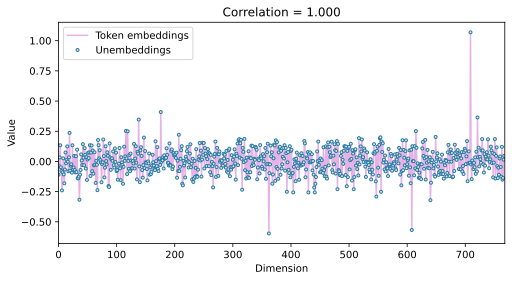

In [9]:
# show that token embedding and final output layer are the same
plt.figure(figsize=(8,4))

tokW = models['small'].transformer.wte.weight[0].detach()
head = models['small'].lm_head.weight[0].detach()

plt.plot(tokW, color=[.9,.7,.9], label='Token embeddings')
plt.plot(head, 'o', markerfacecolor=[.9,.9,.7], markersize=3, label='Unembeddings')

plt.legend()
plt.gca().set(xlabel='Dimension',
              ylabel='Value',
              xlim=[0, len(tokW)],
              title=f'Correlation = {np.corrcoef(tokW,head)[0,1]:.3f}')
plt.show()

## Weight and bias parameters, as percentage of total

In [10]:
for name, mat in models['small'].named_parameters():
    print(name)

transformer.wte.weight
transformer.wpe.weight
transformer.h.0.ln_1.weight
transformer.h.0.ln_1.bias
transformer.h.0.attn.c_attn.weight
transformer.h.0.attn.c_attn.bias
transformer.h.0.attn.c_proj.weight
transformer.h.0.attn.c_proj.bias
transformer.h.0.ln_2.weight
transformer.h.0.ln_2.bias
transformer.h.0.mlp.c_fc.weight
transformer.h.0.mlp.c_fc.bias
transformer.h.0.mlp.c_proj.weight
transformer.h.0.mlp.c_proj.bias
transformer.h.1.ln_1.weight
transformer.h.1.ln_1.bias
transformer.h.1.attn.c_attn.weight
transformer.h.1.attn.c_attn.bias
transformer.h.1.attn.c_proj.weight
transformer.h.1.attn.c_proj.bias
transformer.h.1.ln_2.weight
transformer.h.1.ln_2.bias
transformer.h.1.mlp.c_fc.weight
transformer.h.1.mlp.c_fc.bias
transformer.h.1.mlp.c_proj.weight
transformer.h.1.mlp.c_proj.bias
transformer.h.2.ln_1.weight
transformer.h.2.ln_1.bias
transformer.h.2.attn.c_attn.weight
transformer.h.2.attn.c_attn.bias
transformer.h.2.attn.c_proj.weight
transformer.h.2.attn.c_proj.bias
transformer.h.2.ln_2

In [11]:
# initialize
param_counts = np.zeros((len(models.keys()),3),dtype=int)

for idx,(modelname,model) in enumerate(models.items()):

    # get the summary for all parameters
    sumry = summary(model, input_data=x, col_names=['input_size','output_size','num_params'])
    finalHeadCount = torch.numel(model.lm_head.weight)
    param_counts[idx,2] = sumry.total_params - finalHeadCount

    # loop through all parameters and increment the parameter count
    for layername,mat in model.named_parameters():
        if 'weight' in layername:
            param_counts[idx,0] += torch.numel(mat)
        elif 'bias' in layername:
            param_counts[idx,1] += torch.numel(mat)

    print(f'\n** Model "{modelname}":')
    print(f'Total weights: {param_counts[idx,0]:13,d} ({100*param_counts[idx,0]/param_counts[idx,2]:6.3f}% of all params)')
    print(f'Total biases:  {param_counts[idx,1]:13,d} ({100*param_counts[idx,1]/param_counts[idx,2]:6.3f}% of all params)')


** Model "small":
Total weights:   124,337,664 (99.918% of all params)
Total biases:        102,144 ( 0.082% of all params)

** Model "medium":
Total weights:   354,551,808 (99.924% of all params)
Total biases:        271,360 ( 0.076% of all params)

** Model "large":
Total weights:   773,521,920 (99.934% of all params)
Total biases:        508,160 ( 0.066% of all params)


## Parameters in attention vs. MLP blocks

In [12]:
# initialize
param_counts = np.zeros((len(models.keys()),3),dtype=int)

for idx,(modelname,model) in enumerate(models.items()):

  # get the summary for all parameters
  sumry = summary(model, input_data=x, col_names=['input_size','output_size','num_params'])
  finalHeadCount = torch.numel(model.lm_head.weight)
  param_counts[idx,2] = sumry.total_params - finalHeadCount

  # loop through all parameters and increment parameter count
  for layername,mat in model.named_parameters():
    if ('attn' in layername) and ('weight' in layername):
      param_counts[idx,0] += torch.numel(mat)
    elif ('mlp' in layername) and ('weight' in layername):
      param_counts[idx,1] += torch.numel(mat)

  print(f'\n** Model "{modelname}" ({len(model.transformer.h)} transformer blocks):')
  print(f'Att weights: {param_counts[idx,0]:11,d} ({100*param_counts[idx,0]/param_counts[idx,2]:5.2f}% of all params)')
  print(f'MLP weights: {param_counts[idx,1]:11,d} ({100*param_counts[idx,1]/param_counts[idx,2]:5.2f}% of all params)')


** Model "small" (12 transformer blocks):
Att weights:  28,311,552 (22.75% of all params)
MLP weights:  56,623,104 (45.50% of all params)

** Model "medium" (24 transformer blocks):
Att weights: 100,663,296 (28.37% of all params)
MLP weights: 201,326,592 (56.74% of all params)

** Model "large" (36 transformer blocks):
Att weights: 235,929,600 (30.48% of all params)
MLP weights: 471,859,200 (60.96% of all params)


In [14]:
param_counts.shape

(3, 3)

In [15]:
param_counts[:,0]

array([ 28311552, 100663296, 235929600])

In [16]:
param_counts[:,2]

array([124439808, 354823168, 774030080])

In [17]:
param_counts[:,0] / param_counts[:,2]

array([0.22751202, 0.2836999 , 0.30480676])

In [19]:
np.arange(0,6,2)

array([0, 2, 4])

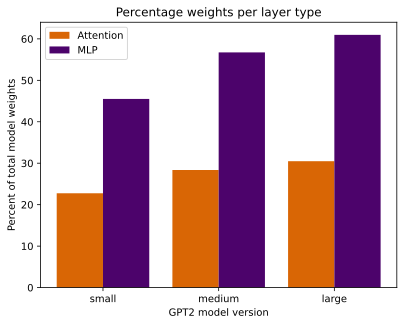

In [21]:
plt.bar(np.arange(0,6,2)-.4,100*param_counts[:,0] / param_counts[:,2],label='Attention',color=[.85,.4,.02])
plt.bar(np.arange(0,6,2)+.4,100*param_counts[:,1] / param_counts[:,2],label='MLP',color=[.3,.01,.42])

plt.legend()
plt.gca().set(xticks=range(0,6,2),xticklabels=models.keys(),xlabel='GPT2 model version',
              ylabel='Percent of total model weights',title='Percentage weights per layer type')
plt.show()

## How many layernorm parameters?

In [22]:
# initialize
param_counts = np.zeros((len(models.keys()),3),dtype=int)

for idx,(modelname,model) in enumerate(models.items()):

  # get the summary for all parameters
  sumry = summary(model, input_data=x, col_names=['input_size','output_size','num_params'])
  finalHeadCount = torch.numel(model.lm_head.weight)
  param_counts[idx,2] = sumry.total_params - finalHeadCount

  # loop through all parameters and increment parameter count
  for layername,mat in model.named_parameters():
    if ('ln_' in layername) and ('weight' in layername):
      param_counts[idx,0] += torch.numel(mat)
    elif ('ln_' in layername) and ('bias' in layername):
      param_counts[idx,1] += torch.numel(mat)

  print(f'\n** Model "{modelname}" ({len(model.transformer.h)} transformer blocks):')
  print(f'LayerNorm weight: {param_counts[idx,0]:11,d} ({100*param_counts[idx,0]/param_counts[idx,2]:5.4f}% of all params)')
  print(f'LayerNorm biases: {param_counts[idx,1]:11,d} ({100*param_counts[idx,1]/param_counts[idx,2]:5.4f}% of all params)')


** Model "small" (12 transformer blocks):
LayerNorm weight:      19,200 (0.0154% of all params)
LayerNorm biases:      19,200 (0.0154% of all params)

** Model "medium" (24 transformer blocks):
LayerNorm weight:      50,176 (0.0141% of all params)
LayerNorm biases:      50,176 (0.0141% of all params)

** Model "large" (36 transformer blocks):
LayerNorm weight:      93,440 (0.0121% of all params)
LayerNorm biases:      93,440 (0.0121% of all params)


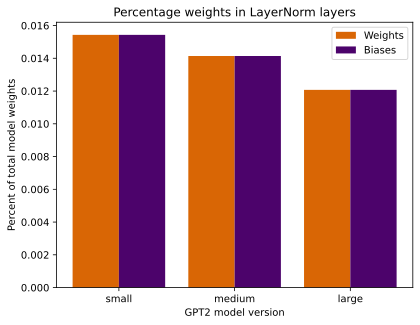

In [23]:
plt.bar(np.arange(0,6,2)-.4,100*param_counts[:,0] / param_counts[:,2],label='Weights',color=[.85,.4,.02])
plt.bar(np.arange(0,6,2)+.4,100*param_counts[:,1] / param_counts[:,2],label='Biases',color=[.3,.01,.42])

plt.legend()
plt.gca().set(xticks=range(0,6,2),xticklabels=models.keys(),xlabel='GPT2 model version',
              ylabel='Percent of total model weights',title='Percentage weights in LayerNorm layers')
plt.show()